# Simulating single-cell data with dynamo

`dynamo.simulation` can generate synthetic single-cell datasets from mechanistic gene-regulatory ODE/SSA models. These are useful for benchmarking RNA-velocity and vector-field methods against a known ground truth (true velocities, true time, true trajectories).

This tutorial covers three built-in models:

1. **Two-gene bifurcation** — a bistable toggle switch.
2. **Two-gene oscillation** — a limit-cycle oscillator.
3. **Neurogenesis** — a 12-gene regulatory network (Qiu et al.), and its metabolic-labeling variant `LabelNeurongenesis`.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

import dynamo as dyn
dyn.configuration.set_figure_params('dynamo', background='white')

## 1. Two-gene bifurcation

`BifurcationTwoGenes` simulates two mutually-inhibiting genes that drive cells toward one of two stable fates. Each model ships with a default parameter dictionary; `simulate` runs the stochastic simulation over `t_span` and `generate_anndata` packages the result (with the ground-truth `time` and `trajectory` in `.obs`).

In [2]:
from dynamo.simulation import BifurcationTwoGenes, bifur2genes_params

bif = BifurcationTwoGenes(param_dict=bifur2genes_params, n_C0s=10)
bif.simulate(t_span=np.linspace(0, 40, 100))
adata_bif = bif.generate_anndata()
adata_bif

|-----> The model contains 2 genes and 2 species


|-----> Adjusting parameters based on `r_aug` and `tau`...


|-----> 10 initial conditions have been created by augmentation.


|-----> 13174 cell with 2 genes stored in AnnData.


AnnData object with n_obs × n_vars = 13174 × 2
    obs: 'trajectory', 'time'
    var: 'a', 'b', 'S', 'K', 'm', 'n', 'gamma'
    layers: 'velocity_T', 'total'

The phase portrait shows the two stable branches; color encodes the ground-truth simulation time.

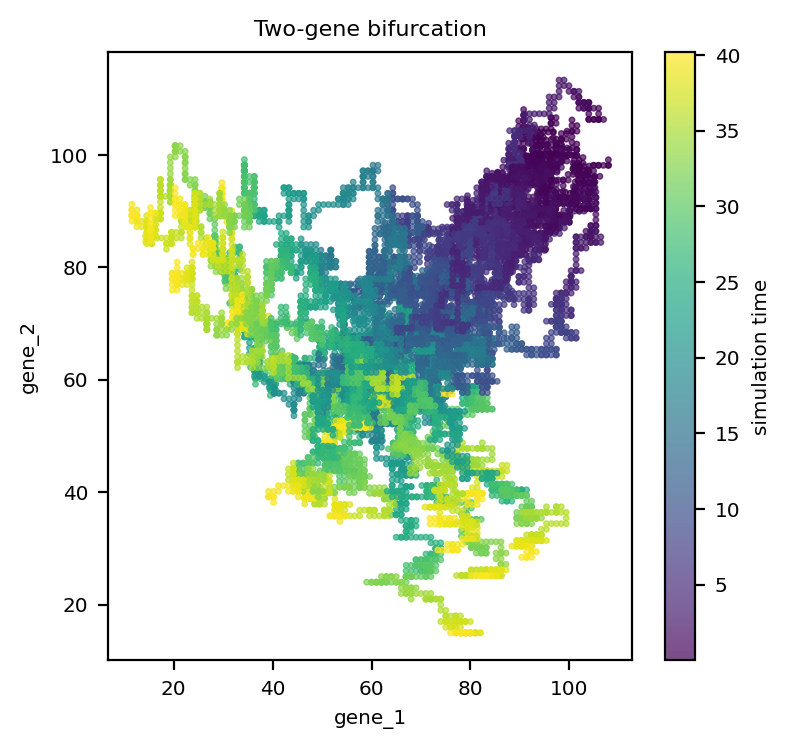

In [3]:
X = adata_bif.X.toarray() if hasattr(adata_bif.X, 'toarray') else np.asarray(adata_bif.X)
fig, ax = plt.subplots(figsize=(4.2, 4))
sc = ax.scatter(X[:, 0], X[:, 1], c=adata_bif.obs['time'].values, s=4, cmap='viridis', alpha=0.7)
ax.set_xlabel(adata_bif.var_names[0]); ax.set_ylabel(adata_bif.var_names[1])
ax.set_title('Two-gene bifurcation')
fig.colorbar(sc, ax=ax, label='simulation time')
plt.show()

## 2. Two-gene oscillation

`OscillationTwoGenes` produces a limit cycle in the two-gene phase plane — a useful stress test for vector-field reconstruction of periodic dynamics.

|-----> The model contains 2 genes and 2 species


|-----> Adjusting parameters based on `r_aug` and `tau`...


|-----> 8 initial conditions have been created by augmentation.


|-----> 23806 cell with 2 genes stored in AnnData.


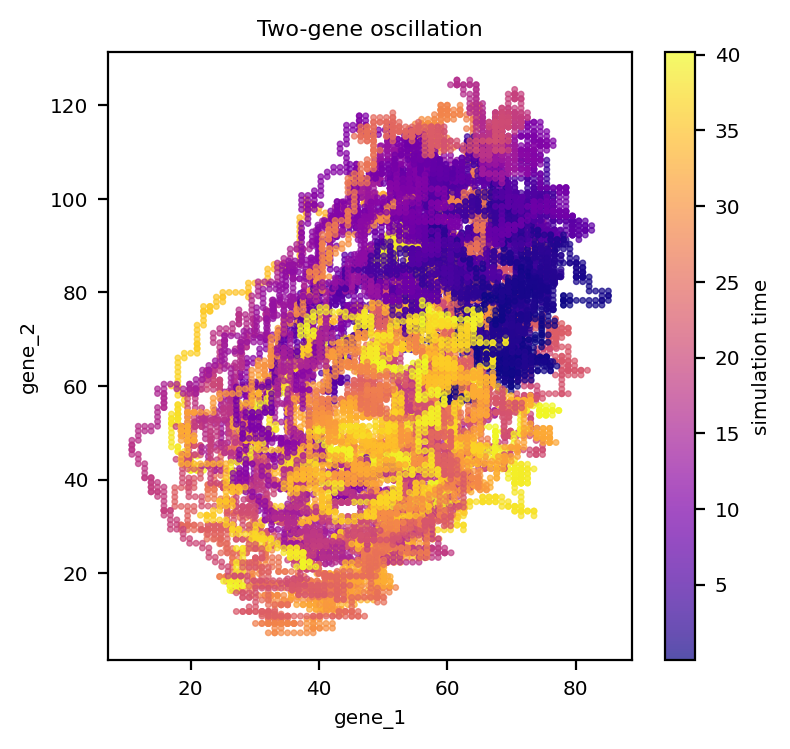

In [4]:
from dynamo.simulation import OscillationTwoGenes, osc2genes_params

osc = OscillationTwoGenes(param_dict=osc2genes_params, n_C0s=8)
osc.simulate(t_span=np.linspace(0, 40, 100))
adata_osc = osc.generate_anndata()

Xo = adata_osc.X.toarray() if hasattr(adata_osc.X, 'toarray') else np.asarray(adata_osc.X)
fig, ax = plt.subplots(figsize=(4.2, 4))
sc = ax.scatter(Xo[:, 0], Xo[:, 1], c=adata_osc.obs['time'].values, s=4, cmap='plasma', alpha=0.7)
ax.set_xlabel(adata_osc.var_names[0]); ax.set_ylabel(adata_osc.var_names[1])
ax.set_title('Two-gene oscillation')
fig.colorbar(sc, ax=ax, label='simulation time')
plt.show()

## 3. Neurogenesis (12-gene network)

`Neurongenesis` simulates a 12-gene regulatory network governing neuronal/glial differentiation (Pax6, Mash1, Hes5, Olig2, ...). The simulation produces many cells along the differentiation trajectories; we subsample for visualization, embed with UMAP, and color by the ground-truth simulation time.

In [5]:
from dynamo.simulation import Neurongenesis, neurongenesis_params

neuro = Neurongenesis(param_dict=neurongenesis_params, n_C0s=3)
neuro.simulate(t_span=np.linspace(0, 30, 40))
adata_neuro = neuro.generate_anndata()

# subsample cells for a quick visualization
rng = np.random.default_rng(0)
idx = rng.choice(adata_neuro.n_obs, size=min(5000, adata_neuro.n_obs), replace=False)
adata_neuro = adata_neuro[idx].copy()
adata_neuro

|-----> The model contains 12 genes and 12 species


|-----> Adjusting parameters based on `r_aug` and `tau`...


|-----> 3 initial conditions have been created by augmentation.


|-----> 347664 cell with 12 genes stored in AnnData.


AnnData object with n_obs × n_vars = 5000 × 12
    obs: 'trajectory', 'time'
    var: 'a', 'K', 'n', 'gamma'
    layers: 'velocity_T', 'total'

|-----> retrieve data for non-linear dimension reduction...


|-----> [UMAP] using X_pca with n_pca_components = 30


|-----> <insert> X_umap to obsm in AnnData Object.


|-----> [UMAP] completed [29.4424s]



╭─ SUMMARY: reduceDimension ─────────────────────────────────────────╮
│  Duration: 29.444s                                                 │
│  Shape:    5,000 x 12 (Unchanged)                                  │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 30, 'method': 'umap'}       │
│           │ ✚ umap_fit                                             │
│                                                                    │
│  ● OBSM   │ ✚ X_umap (array, 5000x2)                               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
|-----------> plotting with basis key=X_umap


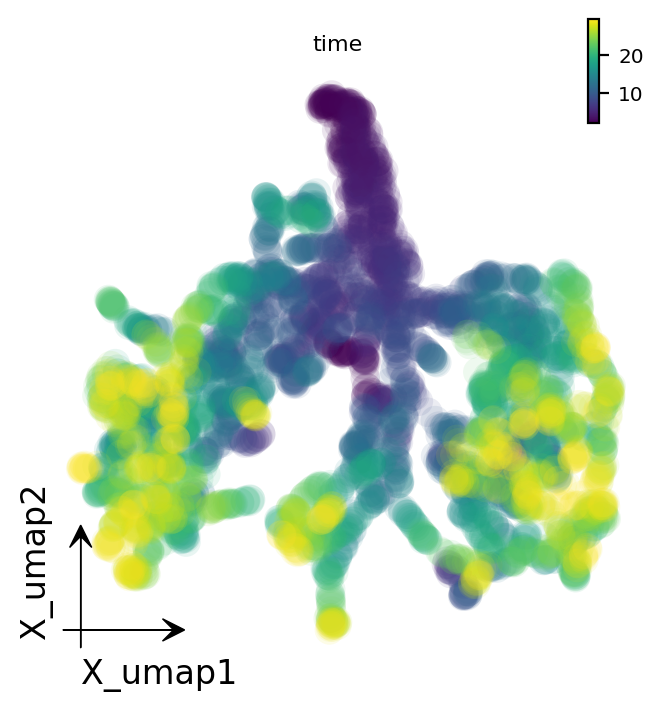

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# log-normalize the small (12-gene) count matrix and embed
M = adata_neuro.X.toarray() if hasattr(adata_neuro.X, 'toarray') else np.asarray(adata_neuro.X)
M = np.log1p(M)
adata_neuro.obsm['X_pca'] = PCA(n_components=10, random_state=0).fit_transform(StandardScaler().fit_transform(M))

dyn.tl.reduceDimension(adata_neuro, basis='pca')
dyn.pl.umap(adata_neuro, color='time', figsize=(4.5, 4), pointsize=0.5)

## 4. Metabolic-labeling variant: `LabelNeurongenesis`

The neurogenesis model also has a metabolic-labeling version (added in [dynamo-release #539](https://github.com/aristoteleo/dynamo-release/pull/539)) that tracks newly synthesized (labeled) vs pre-existing (unlabeled) transcripts — mirroring scNT-seq / scEU-seq experiments and enabling labeling-based velocity. It is constructed the same way, with an added labeling duration.

In [7]:
from dynamo.simulation import LabelNeurongenesis

# LabelNeurongenesis is the labeling-aware counterpart of Neurongenesis.
print(LabelNeurongenesis.__doc__)

None


## Summary

- `dynamo.simulation` provides mechanistic generators (`BifurcationTwoGenes`, `OscillationTwoGenes`, `Neurongenesis`, `LabelNeurongenesis`) that emit standard `AnnData` objects with ground-truth `time`, `trajectory`, and true velocities.
- These are ideal for benchmarking preprocessing, RNA-velocity estimation, and vector-field reconstruction against a known answer.
